# **Shelton–Alcaraz: from a tactical hypothesis to an exploratory game**

**A data-science analysis informed by game theory.** Could a wide serve followed by
an opposite-side serve+1 help Ben Shelton take the initiative against Carlos Alcaraz?

We call this combination **Wide + opposite**: Shelton serves wide, the return lands
in play, and his serve+1 goes to the opposite side of the court.

We start with recorded points, reconsider an initially misleading comparison,
examine Alcaraz's returns, and build a small game using historical performance scores.
The figures illustrate assumptions about adaptation; they are not match forecasts.

Three questions guide the project:
1. Does Wide + opposite perform better than Shelton's other serving patterns?
2. Is its advantage greater for Shelton than for other servers?
3. How does Alcaraz perform when opponents use Wide + opposite?

This notebook addresses **questions 1 and 3**. Question 2 requires a separate,
comparable server-level analysis and remains open.

## 1. Setup and reproducible inputs

Run this notebook **from top to bottom in a fresh Python kernel**, with this repository
as the working directory. All analysis helpers are defined here: there is no `%run`
or import from `shelton_point_features.py`.

Requirements: Python 3.12+, pandas, NumPy, Matplotlib, SciPy, SymPy, IPython and
a Jupyter kernel. The notebook installs the tagged `v0.2.0` release of
[pynamo](https://github.com/SlimaneD/pynamo) directly from its official repository
before the game-theory section.

If a [Match Charting Project](https://github.com/JeffSackmann/tennis_MatchChartingProject)
checkout exists beside this repository, the notebook uses it. Otherwise, it downloads
the two required files from the pinned source revision. The cloud path therefore needs
internet access, as does the pynamo installation cell. Input hashes and the source
revision are displayed at the end; newer charting data can change the estimates.

Figures and tables are exported to `notebook_outputs/`, leaving the earlier published
artifacts untouched. Figures use Matplotlib's portable default fonts and do not
require a LaTeX installation or additional font files.

In [1]:
from pathlib import Path
import re
import sys
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.patheffects as pe
from IPython.display import display

%config InlineBackend.figure_format = "retina"

In [2]:
DATA_REVISION = "2c59eef194967e688b69e73df344184a06322cd8"
DATA_FILENAMES = ["charting-m-matches.csv", "charting-m-points-2020s.csv"]
LOCAL_DATA_DIR = Path("../tennis_MatchChartingProject").resolve()
DOWNLOADED_DATA_DIR = Path("downloaded_data")
DATA_DIR = (LOCAL_DATA_DIR if all((LOCAL_DATA_DIR / name).is_file() for name in DATA_FILENAMES)
            else DOWNLOADED_DATA_DIR)

if DATA_DIR == DOWNLOADED_DATA_DIR:
    DATA_DIR.mkdir(exist_ok=True)
    base_url = ("https://raw.githubusercontent.com/JeffSackmann/"
                f"tennis_MatchChartingProject/{DATA_REVISION}")
    for filename in DATA_FILENAMES:
        destination = DATA_DIR / filename
        if not destination.is_file():
            print("Downloading", filename)
            urlretrieve(f"{base_url}/{filename}", destination)

OUTPUT_DIR = Path("notebook_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

In [3]:
data_files = {
    "matches": DATA_DIR / "charting-m-matches.csv",
    "points": DATA_DIR / "charting-m-points-2020s.csv",
}
for path in data_files.values():
    assert path.is_file(), f"Missing input: {path}. Check DATA_DIR."

matches = pd.read_csv(data_files["matches"])
points = pd.read_csv(data_files["points"], low_memory=False)

shelton_points = points[points["match_id"].str.contains("Shelton", na=False)].copy()
alcaraz_points = points[points["match_id"].str.contains("Alcaraz", na=False)].copy()

relevant = points[
    points["match_id"].isin(set(shelton_points.match_id) | set(alcaraz_points.match_id))
].copy()

display(pd.DataFrame({
    "Points": [len(shelton_points), len(alcaraz_points)],
    "Matches": [shelton_points.match_id.nunique(), alcaraz_points.match_id.nunique()],
}, index=["Matches involving Shelton", "Matches involving Alcaraz"]))

,Points,Matches
Matches involving Shelton,8169,44
Matches involving Alcaraz,36635,219


### Can every point be linked to the right players?

`Svr=1` means **Player 1 in the match metadata**, not always Shelton. We use the
metadata rather than infer player numbers from the filename. The matches file covers
more years than the 2020s points file, so full equality of match sets is unnecessary.
Every match used here must have one unambiguous metadata record.

Exact duplicate metadata rows are collapsed; conflicting records and duplicate point
IDs stop the analysis. These checks are restricted to the matches we use.

In [4]:
point_ids = set(points.match_id.dropna())
match_ids = set(matches.match_id.dropna())
print("Point matches without metadata:", len(point_ids - match_ids))
assert relevant.match_id.notna().all()
assert set(relevant.match_id) <= match_ids, "Missing metadata for relevant matches"
assert not relevant.duplicated(["match_id", "Pt"]).any(), "Duplicate point IDs"

metadata_columns = ["match_id", "Player 1", "Player 2", "Pl 1 hand", "Pl 2 hand", "Surface"]
metadata = matches.loc[matches.match_id.isin(relevant.match_id), metadata_columns].drop_duplicates()
assert not metadata.match_id.duplicated().any(), "Conflicting match metadata"
relevant = relevant.merge(metadata, on="match_id", validate="many_to_one")
assert relevant.Svr.isin([1, 2]).all()

first_player_serves = relevant.Svr.eq(1)
relevant["server"] = relevant["Player 1"].where(first_player_serves, relevant["Player 2"])
relevant["returner"] = relevant["Player 2"].where(first_player_serves, relevant["Player 1"])
relevant["server_hand"] = relevant["Pl 1 hand"].where(first_player_serves, relevant["Pl 2 hand"])
relevant["server_hand"] = relevant.server_hand.astype("string").str.strip().str.upper()

Point matches without metadata: 0


## 2. What do `1st` and `2nd` encode?

Each row is one point. `1st` records the first serve **and the rally if it starts the
point**; `2nd` records the second serve and rally after a first-serve fault.

| Code | Meaning |
|---|---|
| Serve `4`, `5`, `6` | Wide, body, T; unchanged by court side or handedness |
| Shot `f`, `b`, `r`, `s` | Forehand, backhand, forehand slice, backhand slice |
| Direction `1`, `2`, `3` | Right-hander's forehand court side, middle, backhand court side |
| Return depth `7`, `8`, `9` | Service boxes, moderately deep, deepest quarter |
| `*`, `#`, `@` | Winner, forced error, unforced error |
| `n`, `w`, `d`, `x` | Net, wide, long, wide and long error |
| `0`, `q` | Unknown direction/depth, unknown shot type |

For a **left-handed server**, return direction `1` targets their backhand side and
`3` their forehand side. It does not determine the stroke they actually hit.

Sources: the local `data_dictionary.txt`, the **Instructions** sheet of the source
spreadsheet, and the [official notation guide](https://www.tennisabstract.com/blog/2015/09/23/the-match-charting-project-quick-start-guide/).
Direction and depth annotations are optional. Missing information stays missing.

### The eight readable features we extract

| Feature | Interpretation |
|---|---|
| `serve_number` | 1 or 2; 0 for a double fault; unknown if sequence unavailable |
| `serve_wide` | Whether the rally-starting serve was wide; missing for double faults |
| `return_type` | Stroke used by the returner |
| `return_direction` | Targeted side of the server's court, accounting for handedness |
| `return_depth` | Short / medium / deep / missing |
| `return_in_play` | Successful return, including a return winner |
| `serve_plus_one_to_opposite_side` | Wide serve then opposite-side attempt; missing when unclassifiable |
| `point_won` | **Server** won; we name Alcaraz's outcome explicitly later |

A serve+1 error still counts as an attempted shot. For a wide serve, the opposite
court-side target is `3` on deuce points and `1` on ad points, regardless of handedness.
Serve direction, court side and serve+1 type need not become public analysis columns.

In [5]:
SHOT_TYPES = {
    "f": "forehand", "b": "backhand",
    "r": "forehand_slice", "s": "backhand_slice",
    "v": "forehand_volley", "z": "backhand_volley",
    "o": "overhead", "p": "backhand_overhead",
    "u": "forehand_drop_shot", "y": "backhand_drop_shot",
    "l": "forehand_lob", "m": "backhand_lob",
    "h": "forehand_half_volley", "i": "backhand_half_volley",
    "j": "forehand_swinging_volley", "k": "backhand_swinging_volley",
    "t": "trick_shot", "q": "unknown",
}
shot_letters = "".join(SHOT_TYPES)
SHOT_PATTERN = re.compile(rf"([{shot_letters}])([^{shot_letters}]*)")
DIRECTION_PATTERN = re.compile(r"^[+\-=;^]*([0123])")
DEPTH_PATTERN = re.compile(r"^[+\-=;^]*[0123]([0789])")
SERVE_PATTERN = re.compile(r"^c*([0456])")
FAULT_PATTERN = re.compile(r"^c*[0456][+\-=;^]*[nwdxe!]+$")

In [6]:
def clean_sequence(value):
    return "" if pd.isna(value) else str(value).strip()


def shot_direction(annotations):
    match = DIRECTION_PATTERN.match(annotations)
    return int(match.group(1)) if match and match.group(1) != "0" else None


def return_depth(annotations):
    match = DEPTH_PATTERN.match(annotations)
    return {"7": "short", "8": "medium", "9": "deep"}.get(
        match.group(1) if match else None, pd.NA
    )


def return_side(direction, server_hand):
    if direction == 2:
        return "middle"
    labels = {"R": {1: "forehand", 3: "backhand"},
              "L": {1: "backhand", 3: "forehand"}}
    return labels.get(server_hand, {}).get(direction, pd.NA)

### Determine deuce/ad side internally

The CSV is not necessarily in point order. Sort by numeric `Pt`, then count points
within each game: standard games and tiebreaks both start on deuce and alternate.
We use **all points**, including points that will later be excluded from the analysis.
Tied game scores such as 1–1 do not imply a tiebreak.

This assumes complete point sequences and conventional court-side alternation.
The completeness check below passes for this snapshot. No-ad deciding points or other
unusual formats would require an explicit court-side override from the notes/video.

In [7]:
point_order = relevant[["match_id", "Pt", "Gm#"]].copy()
point_order["Pt"] = pd.to_numeric(point_order.Pt)
point_order = point_order.sort_values(["match_id", "Pt"])
completeness = point_order.groupby("match_id").Pt.agg(["min", "max", "count"])
assert completeness["min"].eq(1).all()
assert completeness["max"].eq(completeness["count"]).all(), "Incomplete point sequences"
point_order["game"] = point_order["Gm#"].astype(str).str.extract(r"^(\d+)", expand=False)
assert point_order.game.notna().all(), "Unknown game number format"
point_order["deuce"] = point_order.groupby(["match_id", "game"]).cumcount().mod(2).eq(0)
deuce_lookup = point_order.set_index(["match_id", "Pt"])["deuce"]

### Parse the serve, then the return and follow-up

The next small helpers separate the three decisions. Unrecorded `S`/`R` point
sequences retain the known winner but do not invent serve information. The parser
covers the notation used in this analysis; it is not a full reconstruction of every
challenge, penalty or unusual charting event.

In [8]:
def serve_context(row):
    first, second = clean_sequence(row["1st"]), clean_sequence(row["2nd"])
    sequence = second or first
    serve = SERVE_PATTERN.match(sequence)
    if serve is None:
        return pd.NA, None, []
    if second and FAULT_PATTERN.fullmatch(second):
        return 0, None, []
    if not second and FAULT_PATTERN.fullmatch(first):
        return pd.NA, None, []
    shots = SHOT_PATTERN.findall(sequence[serve.end():])
    return (2 if second else 1), serve.group(1), shots


def return_features(shots, sequence, server_hand):
    result = dict(return_type=pd.NA, return_direction=pd.NA,
                  return_depth=pd.NA, return_in_play=pd.NA)
    if not shots:
        if "*" in sequence or "#" in sequence:
            result["return_in_play"] = False
        return result
    code, annotations = shots[0]
    result.update(return_type=SHOT_TYPES[code],
                  return_direction=return_side(shot_direction(annotations), server_hand),
                  return_depth=return_depth(annotations))
    if "@" in annotations or "#" in annotations:
        result["return_in_play"] = False
    elif "*" in annotations or len(shots) >= 2:
        result["return_in_play"] = True
    return result

In [9]:
def opposite_side(row, direction, shots):
    if direction != "4" or len(shots) < 2:
        return pd.NA
    target = shot_direction(shots[1][1])
    if target is None:
        return pd.NA
    deuce = bool(deuce_lookup.loc[(row["match_id"], int(row["Pt"]))])
    return target == (3 if deuce else 1)


def describe_point(row):
    number, direction, shots = serve_context(row)
    result = dict(serve_number=number, serve_wide=pd.NA,
                  return_type=pd.NA, return_direction=pd.NA, return_depth=pd.NA,
                  return_in_play=pd.NA, serve_plus_one_to_opposite_side=pd.NA,
                  point_won=pd.NA if pd.isna(row["PtWinner"])
                  else int(row["PtWinner"]) == int(row["Svr"]))
    if pd.isna(number):
        return pd.Series(result)
    if number == 0:
        result["return_in_play"] = False
        return pd.Series(result)
    if direction != "0":
        result["serve_wide"] = direction == "4"
    sequence = clean_sequence(row["2nd"]) or clean_sequence(row["1st"])
    result.update(return_features(shots, sequence, row["server_hand"]))
    result["serve_plus_one_to_opposite_side"] = opposite_side(row, direction, shots)
    return pd.Series(result)

In [10]:
# Parse only the service/return populations used below, once each per point.
analysis_points = relevant[
    relevant.server.eq("Ben Shelton") | relevant.returner.eq("Carlos Alcaraz")
].copy()
features = analysis_points.apply(describe_point, axis=1)
features["serve_number"] = features.serve_number.astype("Int64")
boolean_columns = ["serve_wide", "return_in_play", "serve_plus_one_to_opposite_side", "point_won"]
features[boolean_columns] = features[boolean_columns].astype("boolean")
analysis_points[features.columns] = features

shelton_serve_points = analysis_points[analysis_points.server.eq("Ben Shelton")].copy()
alcaraz_return_points = analysis_points[analysis_points.returner.eq("Carlos Alcaraz")].copy()
alcaraz_return_points["server_won"] = alcaraz_return_points.point_won
alcaraz_return_points["alcaraz_won"] = ~alcaraz_return_points.server_won

assert (alcaraz_return_points.alcaraz_won.astype("Int64")
        + alcaraz_return_points.server_won.astype("Int64")).dropna().eq(1).all()
display(shelton_serve_points[["match_id", "Pt", "1st", "2nd"] + list(features.columns)].head())

,match_id,Pt,1st,2nd,serve_number,serve_wide,return_type,return_direction,return_depth,return_in_play,serve_plus_one_to_opposite_side,point_won
0,20260417-M-Munich-QF-Ben_Shelton-Joao_Fonseca,1,4w,6#,2,False,NaN,NaN,NaN,False,<NA>,True
8,20260417-M-Munich-QF-Ben_Shelton-Joao_Fonseca,66,6d,4f18y2s-3f3z1b1*,2,True,forehand,forehand,medium,True,False,True
9,20260417-M-Munich-QF-Ben_Shelton-Joao_Fonseca,67,6*,NaN,1,False,NaN,NaN,NaN,False,<NA>,True
10,20260417-M-Munich-QF-Ben_Shelton-Joao_Fonseca,68,6s18f3*,NaN,1,False,backhand_slice,forehand,medium,True,<NA>,True
11,20260417-M-Munich-QF-Ben_Shelton-Joao_Fonseca,69,6d,4#,2,True,NaN,NaN,NaN,False,<NA>,True


### Sanity checks before interpreting win rates

Verify a documented example: `6d / 6b27f3*` means first serve long, second serve T,
a short middle backhand return, then a forehand serve+1 winner. Also check left-handed
court-side labels, double faults, no follow-up after an ace, and unknown directions.
These checks protect the meaning of the features rather than merely whether code runs.

In [11]:
example = shelton_serve_points[
    shelton_serve_points.match_id.eq("20250601-M-Roland_Garros-R16-Ben_Shelton-Carlos_Alcaraz")
    & shelton_serve_points.Pt.eq(1)
]
if not example.empty:
    row = example.iloc[0]
    assert row["1st"] == "6d" and row["2nd"] == "6b27f3*"
    assert row.serve_number == 2 and not row.serve_wide
    assert row.return_direction == "middle" and row.return_depth == "short"
    assert row.point_won
assert return_side(1, "L") == "backhand" and return_side(3, "L") == "forehand"
assert return_side(1, "R") == "forehand" and return_side(3, "R") == "backhand"
assert serve_context({"1st": "4n", "2nd": "6d"})[0] == 0
assert not return_features([], "4*", "L")["return_in_play"]
assert shot_direction("0*") is None

display(shelton_serve_points.serve_number.value_counts(dropna=False).rename("Points"))

serve_number
1       2738
2       1251
0        170
<NA>       1
Name: Points, dtype: Int64

In [12]:
# Choose an arbitrary point.
point = analysis_points.sample(n=1, random_state=40).iloc[0]

print("Raw point")
print("---------")
print("Match:", point["match_id"])
print("Point:", point["Pt"])
print("Server:", point["server"])
print("Returner:", point["returner"])
print("1st:", point["1st"])
print("2nd:", point["2nd"])

print("\nInterpretation")
print("--------------")

interpretation = describe_point(point)

for feature, value in interpretation.items():
    print(f"{feature}: {value}")

Raw point
---------
Match: 20240122-M-Australian_Open-R16-Miomir_Kecmanovic-Carlos_Alcaraz
Point: 118
Server: Miomir Kecmanovic
Returner: Carlos Alcaraz
1st: 5f18f3b3d@
2nd: nan

Interpretation
--------------
serve_number: 1
serve_wide: False
return_type: forehand
return_direction: forehand
return_depth: medium
return_in_play: True
serve_plus_one_to_opposite_side: <NA>
point_won: True


In [13]:
# Select a reproducible arbitrary point with a recorded rally.
has_rally = (
    analysis_points["1st"].fillna("").str.contains(f"[{shot_letters}]")
    | analysis_points["2nd"].fillna("").str.contains(f"[{shot_letters}]")
)

point = analysis_points[has_rally].sample(
    n=1,
    random_state=14,
).iloc[0]

server_hand = point["server_hand"]
returner_hand = (
    point["Pl 2 hand"] if point["Svr"] == 1
    else point["Pl 1 hand"]
)

print("Raw notation")
print("------------")
print("1st:", clean_sequence(point["1st"]) or "not recorded")
print("2nd:", clean_sequence(point["2nd"]) or "not played")

print("\nInterpretation")
print("--------------")

serve_names = {
    "0": "in an unknown direction",
    "4": "wide",
    "5": "to the body",
    "6": "down the T",
}

for serve_number, column in [(1, "1st"), (2, "2nd")]:
    sequence = clean_sequence(point[column])

    if not sequence:
        continue

    serve = SERVE_PATTERN.match(sequence)

    if serve is None:
        print(f"Serve {serve_number}: unrecognized sequence")
        continue

    print(
        f"Serve {serve_number}: {point['server']} serves "
        f"{serve_names[serve.group(1)]}"
    )

    shots = SHOT_PATTERN.findall(sequence[serve.end():])

    if not shots:
        if "*" in sequence:
            print("  Outcome: ace")
        elif "#" in sequence:
            print("  Outcome: unreturned serve")
        elif any(error in sequence for error in "nwdxe!"):
            print("  Outcome: service fault")
        continue

    for shot_index, (shot_code, annotations) in enumerate(shots):
        is_return = shot_index == 0
        is_server_shot = shot_index % 2 == 1

        player = point["server"] if is_server_shot else point["returner"]
        target_hand = returner_hand if is_server_shot else server_hand

        if is_return:
            shot_name = "Return"
        elif shot_index == 1:
            shot_name = "Serve+1"
        else:
            shot_name = f"Rally shot {shot_index + 1}"

        direction = shot_direction(annotations)
        side = return_side(direction, target_hand)

        text = f"{shot_name}: {player} hits a {SHOT_TYPES[shot_code]}"

        if pd.notna(side):
            text += f" toward the opponent's {side} side"

        if is_return:
            depth = return_depth(annotations)
            if pd.notna(depth):
                text += f", {depth}"

        if "n" in annotations:
            text += ", into the net"
        elif "w" in annotations:
            text += ", wide"
        elif "d" in annotations:
            text += ", long"
        elif "x" in annotations:
            text += ", wide and long"

        if "*" in annotations:
            text += " — winner"
        elif "#" in annotations:
            text += " — forced error"
        elif "@" in annotations:
            text += " — unforced error"

        print(text)

Raw notation
------------
1st: 6n
2nd: 4b27f+3s3n#

Interpretation
--------------
Serve 1: Jiri Lehecka serves down the T
  Outcome: service fault
Serve 2: Jiri Lehecka serves wide
Return: Carlos Alcaraz hits a backhand toward the opponent's middle side, short
Serve+1: Jiri Lehecka hits a forehand toward the opponent's backhand side
Rally shot 3: Carlos Alcaraz hits a backhand_slice toward the opponent's backhand side, into the net — forced error


## 3. Does Wide + opposite outperform Shelton's alternatives?

### First attempt: compare with all first serves

An initial comparison might contrast Wide + opposite with all of Shelton’s first-serve points. However, the two groups are not directly comparable.
Identifying Wide + opposite requires the opponent to return the serve and Shelton to attempt a serve+1 shot. By contrast, the overall first-serve win rate also includes aces and missed returns—points that strongly favor the server but offer no opportunity to observe a serve+1.
The comparison is still informative, but it cannot isolate the performance of Wide + opposite.

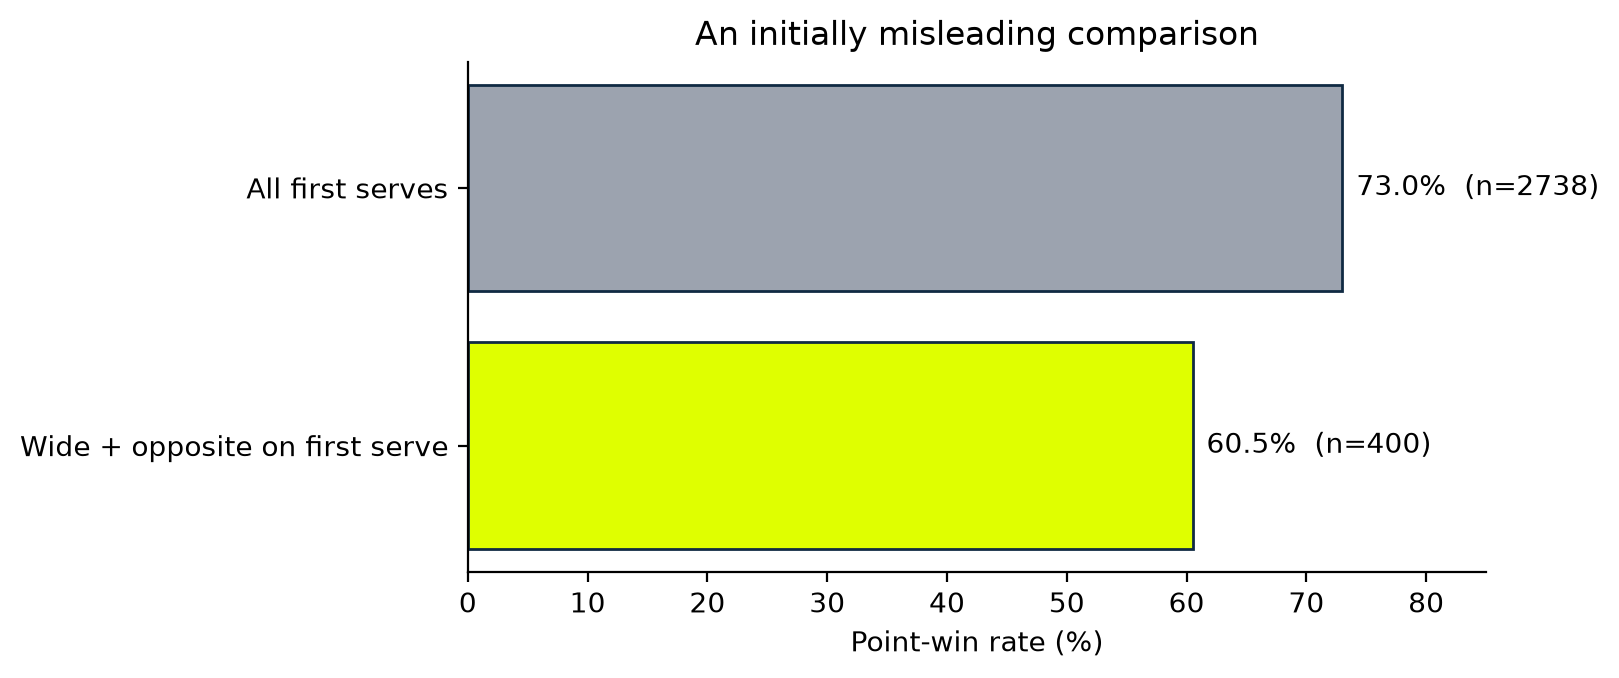

In [14]:
def summarize_groups(groups, outcome="point_won"):
    return pd.DataFrame({name: {
        "Points": len(frame), "Known outcomes": frame[outcome].count(),
        "Success rate (%)": frame[outcome].mean() * 100,
    } for name, frame in groups.items()}).T.astype({"Points": int, "Known outcomes": int}).round(2)

def plot_success_rates(table, title, colors=None):
    fig, ax = plt.subplots(figsize=(8, 3.5))
    bars = ax.barh(table.index, table["Success rate (%)"], color=colors, edgecolor="#102A43")
    labels = [f"{rate:.1f}%  (n={int(n)})" for rate, n in
              zip(table["Success rate (%)"], table["Points"])]
    ax.bar_label(bars, labels=labels, padding=5)
    ax.set(xlabel="Point-win rate (%)", title=title,
           xlim=(0, max(65, table["Success rate (%)"].max() + 12)))
    ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    return fig, ax

first_serve = shelton_serve_points[shelton_serve_points.serve_number.eq(1)]
first_wide_opposite = first_serve[
    first_serve.serve_wide.eq(True) & first_serve.serve_plus_one_to_opposite_side.eq(True)
]
first_serve_comparison = summarize_groups({"All first serves": first_serve,
                                             "Wide + opposite on first serve": first_wide_opposite})
plot_success_rates(first_serve_comparison, "An initially misleading comparison",
                   colors=["#9CA3AF", "#DFFF00"]);

### Restrict to returns in play, then separate three patterns

1. Wide serve → opposite-side serve+1.
2. Wide serve → serve+1 elsewhere.
3. Non-wide serve, irrespective of the next shot.

Include serve+1 errors as attempts. Exclude unknown classifications instead of treating
them as alternatives. **Return winners remain in the non-wide group**, whereas wide
return winners have no classifiable follow-up. This retains the original comparison
but is a selection asymmetry to remember. Results describe recorded patterns, not the
causal effect of deciding on a plan before serving.

Unclassified returns in play: 54


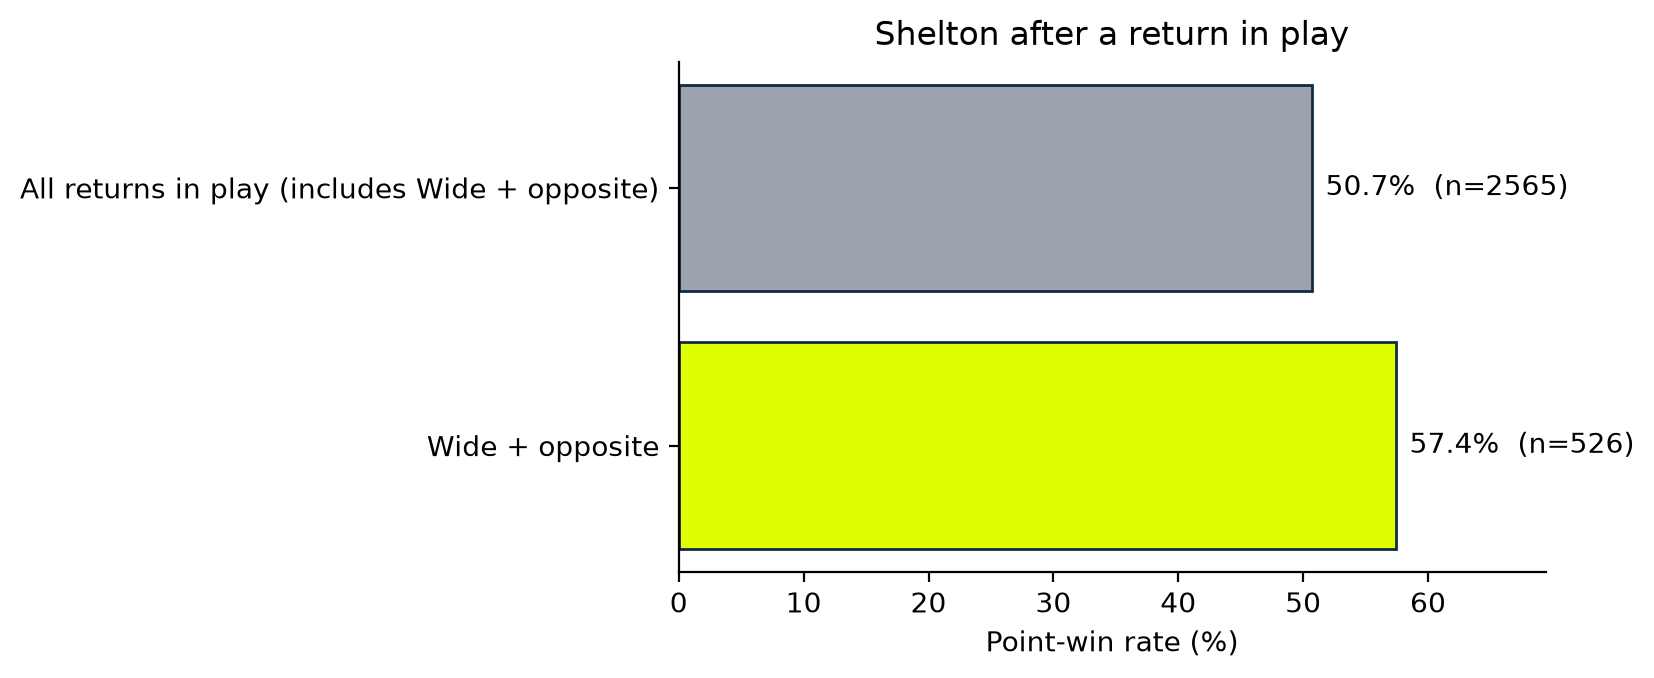

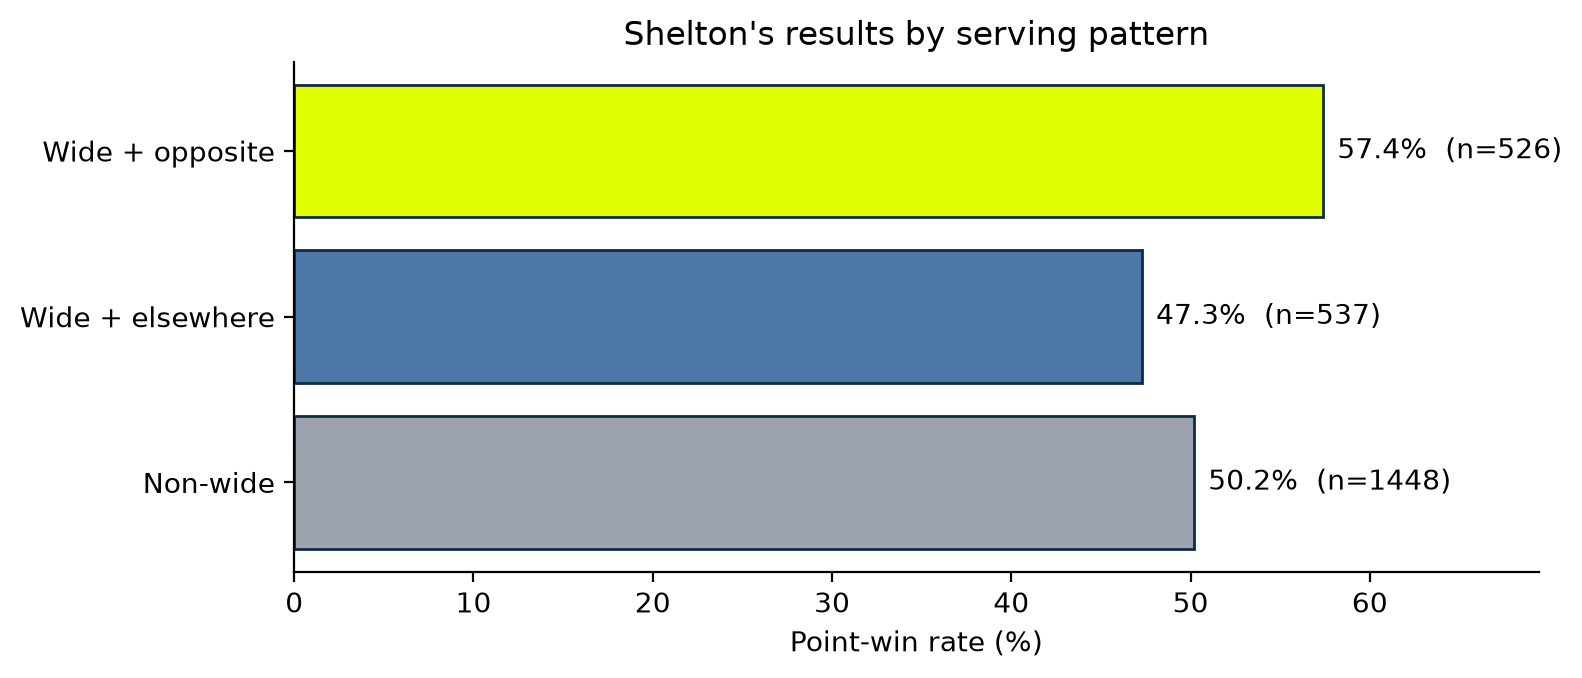

In [15]:
strategy_order = ["Wide + opposite", "Wide + elsewhere", "Non-wide"]

def classify_patterns(frame):
    result = frame[frame.return_in_play.eq(True)].copy()
    result["strategy"] = pd.Series(pd.NA, index=result.index, dtype="string")
    wide = result.serve_wide.eq(True)
    opposite = result.serve_plus_one_to_opposite_side
    result.loc[wide & opposite.eq(True), "strategy"] = strategy_order[0]
    result.loc[wide & opposite.eq(False), "strategy"] = strategy_order[1]
    result.loc[result.serve_wide.eq(False), "strategy"] = strategy_order[2]
    return result

shelton_patterns = classify_patterns(shelton_serve_points)
strategy_points = shelton_patterns.dropna(subset=["strategy"]).copy()
strategy_points["strategy"] = pd.Categorical(strategy_points.strategy, strategy_order, ordered=True)
wide_opposite_points = strategy_points[strategy_points.strategy.eq(strategy_order[0])]
wide_not_opposite = strategy_points[strategy_points.strategy.eq(strategy_order[1])]
not_wide = strategy_points[strategy_points.strategy.eq(strategy_order[2])]

print("Unclassified returns in play:", int(shelton_patterns.strategy.isna().sum()))
return_comparison = summarize_groups({"All returns in play (includes Wide + opposite)": shelton_patterns,
                                      "Wide + opposite": wide_opposite_points})
plot_success_rates(return_comparison, "Shelton after a return in play",
                   colors=["#9CA3AF", "#DFFF00"]);
comparison = summarize_groups(dict(zip(strategy_order, [wide_opposite_points, wide_not_opposite, not_wide])))
strategy_colors = {"Wide + opposite": "#DFFF00", "Wide + elsewhere": "#4C78A8",
                   "Non-wide": "#9CA3AF"}
plot_success_rates(comparison, "Shelton's results by serving pattern",
                   colors=[strategy_colors[name] for name in comparison.index]);

### Do serve number and return quality change the comparison?

A first serve and a second serve create different situations. A short return may make
opposite-side play easier. Split the same comparison by serve number and return depth;
keep counts and unknown depth visible. Small subgroups should not drive strong claims.

Return depth is measured **after** the serve: conditioning on it helps investigate the
follow-up choice but may remove part of the wide serve's benefit. Direction/depth are
not measures of spin, pace, receiver displacement, or intended tactics.

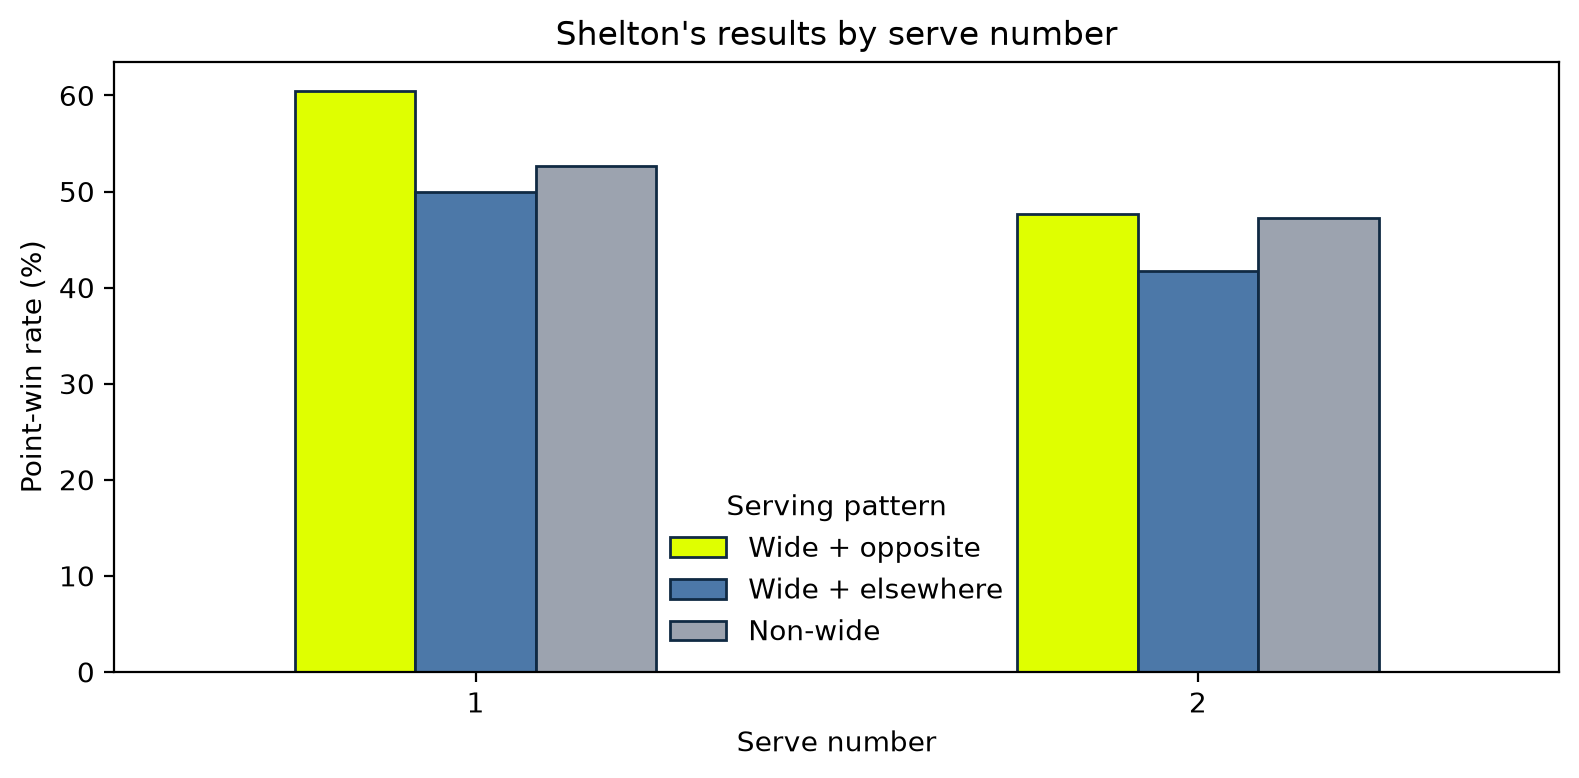

In [16]:
def performance_table(frame, groups, outcome="point_won"):
    table = frame.groupby(groups, observed=True).agg(
        Points=(outcome, "size"), Known_outcomes=(outcome, "count"),
        Points_won=(outcome, "sum"), Success_rate=(outcome, "mean"),
    )
    table["Success_rate"] *= 100
    return table.rename(columns={"Success_rate": "Success rate (%)"}).round(2)

strategy_points["return_depth"] = pd.Categorical(
    strategy_points.return_depth.fillna("unknown"),
    ["short", "medium", "deep", "unknown"], ordered=True,
)
serve_summary = performance_table(strategy_points, ["serve_number", "strategy"])
serve_rates = serve_summary["Success rate (%)"].unstack("strategy").reindex(columns=strategy_order)
serve_rates.plot.bar(color=[strategy_colors[name] for name in strategy_order],
                     edgecolor="#102A43", figsize=(8, 4))
plt.xlabel("Serve number"); plt.ylabel("Point-win rate (%)")
plt.title("Shelton's results by serve number"); plt.xticks(rotation=0)
plt.legend(title="Serving pattern", frameon=False); plt.tight_layout(); plt.show()

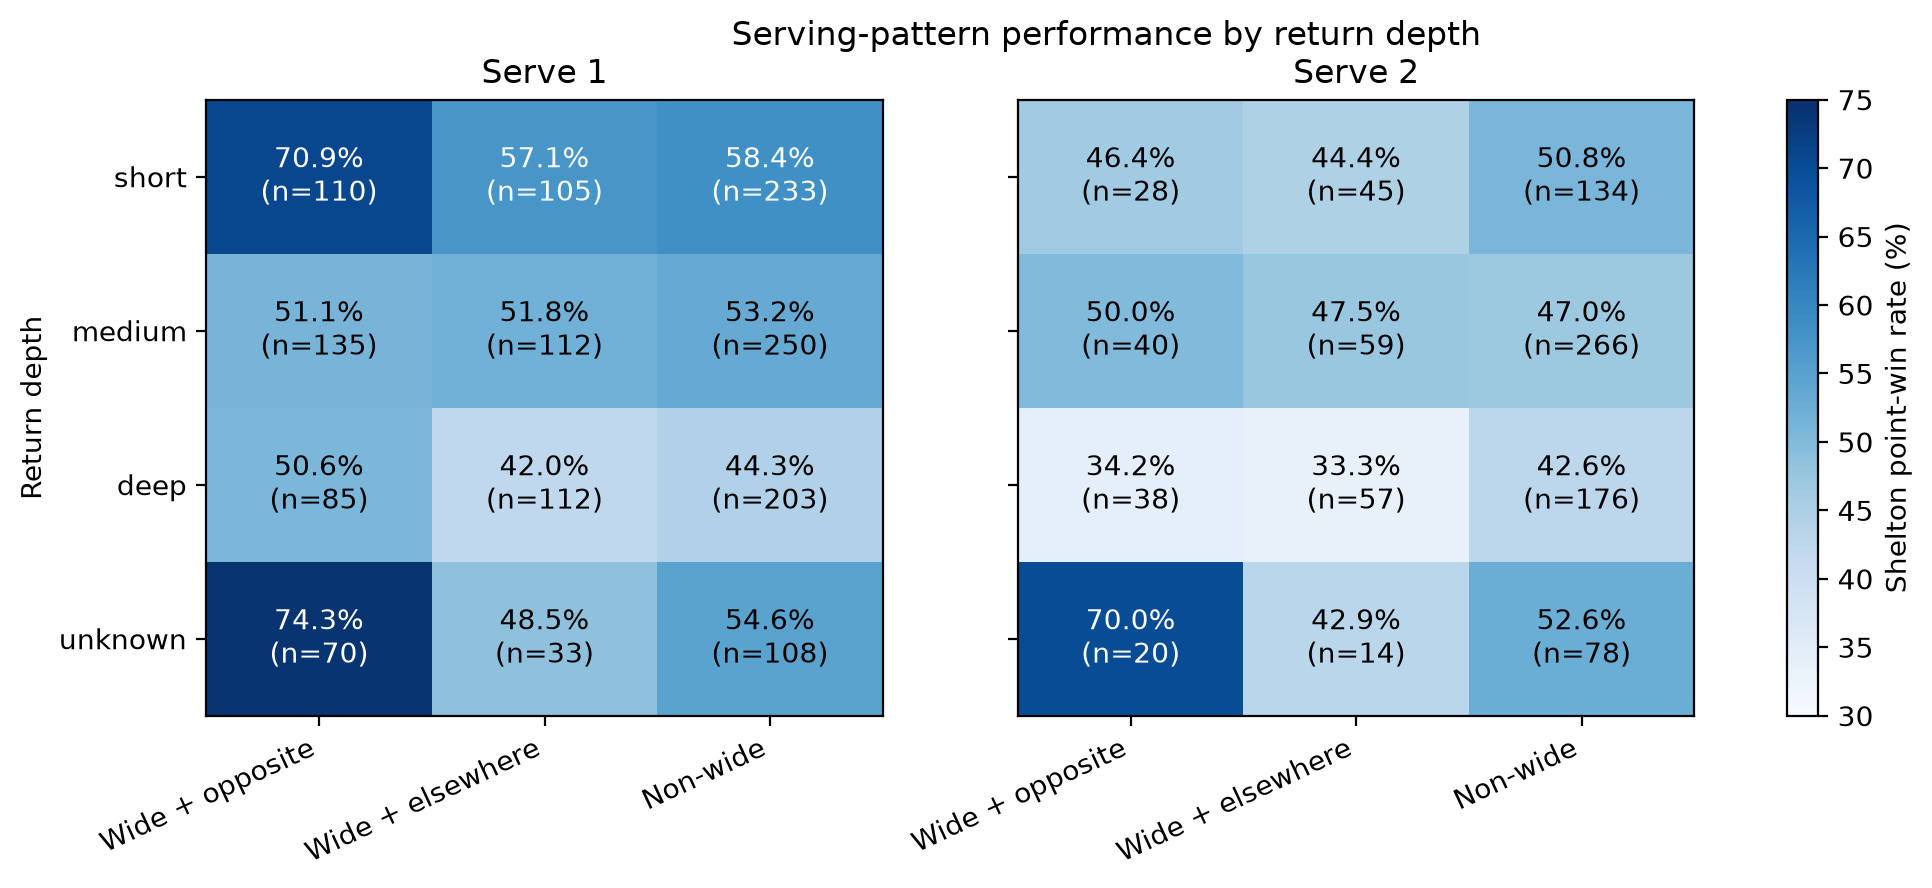

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, serve_number in zip(axes, [1, 2]):
    subset = strategy_points[strategy_points.serve_number.eq(serve_number)]
    summary = performance_table(subset, ["return_depth", "strategy"])
    rates = summary["Success rate (%)"].unstack("strategy").reindex(
        index=["short", "medium", "deep", "unknown"], columns=strategy_order).astype(float)
    image = ax.imshow(rates, cmap="Blues", vmin=30, vmax=75, aspect="auto")
    ax.set_xticks(range(3), strategy_order, rotation=25, ha="right")
    ax.set_yticks(range(4), rates.index)
    ax.set_title(f"Serve {serve_number}")
    for i in range(4):
        for j in range(3):
            rate = rates.iloc[i, j]
            n = summary.loc[(rates.index[i], strategy_order[j]), "Points"] if pd.notna(rate) else 0
            ax.text(j, i, "--" if pd.isna(rate) else f"{rate:.1f}%\n(n={int(n)})",
                    ha="center", va="center", color="white" if rate > 55 else "black")
axes[0].set_ylabel("Return depth")
fig.colorbar(image, ax=axes, label="Shelton point-win rate (%)")
fig.suptitle("Serving-pattern performance by return depth")
plt.show()

## 4. How does Alcaraz respond to opponents using Wide + opposite?

We now examine points where **Alcaraz is returning**, rather than serving.
`server_won` indicates whether his opponent won the point, while `alcaraz_won`
indicates whether Alcaraz won it. The two outcomes are complementary.

This analysis pools Alcaraz's return points against all his charted opponents.
It includes their one available Shelton–Alcaraz match, but the results primarily
describe how Alcaraz has performed against the wider group of servers.

We apply the same return-in-play restriction and Wide + opposite classification rules used
in the Shelton analysis.

Unclassified returns in play: 186


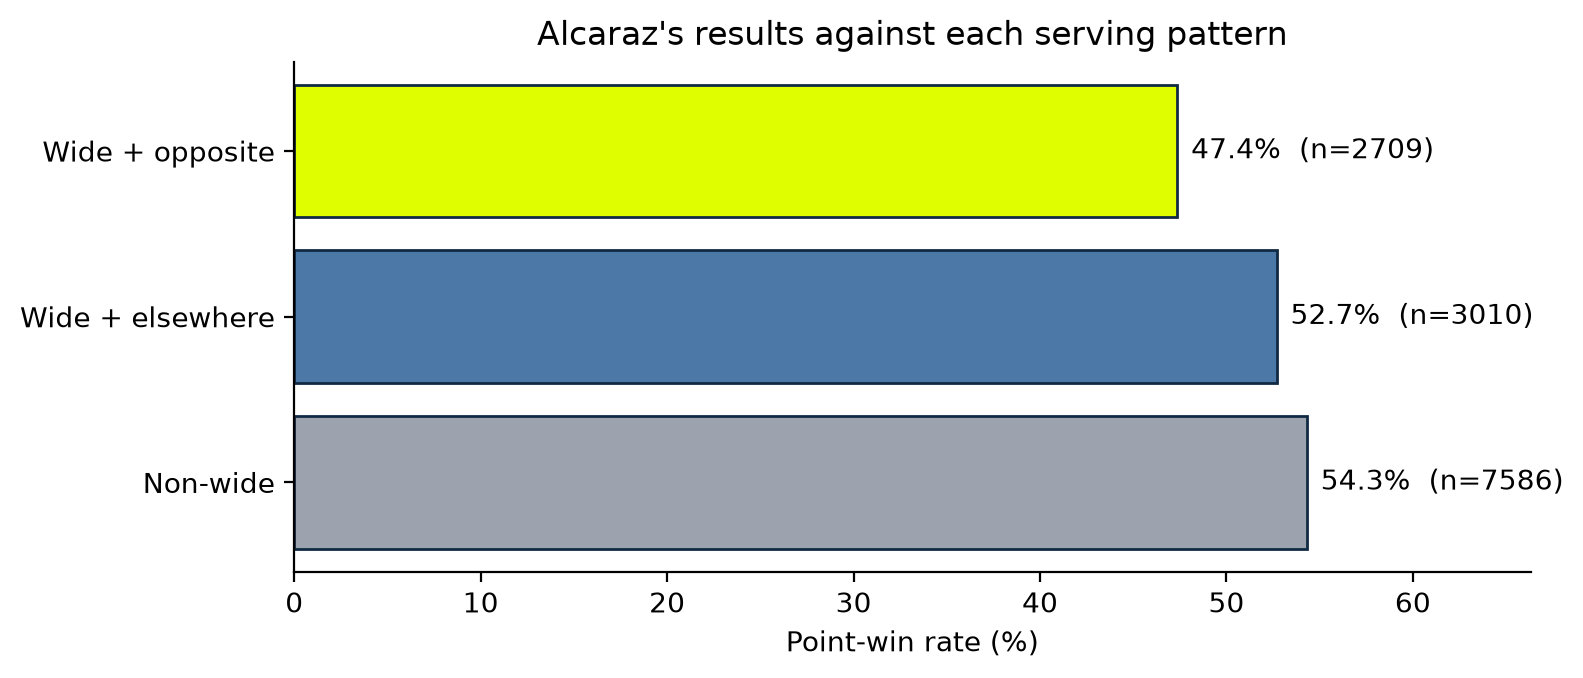

In [18]:
alcaraz_patterns = classify_patterns(alcaraz_return_points)
alcaraz_classified = alcaraz_patterns.dropna(subset=["strategy"]).copy()
alcaraz_classified["strategy"] = pd.Categorical(alcaraz_classified.strategy, strategy_order, ordered=True)
comparison_alcaraz = alcaraz_classified.groupby("strategy", observed=True).agg(
    Points=("alcaraz_won", "size"),
    Alcaraz_success_rate=("alcaraz_won", "mean"),
    Opponent_success_rate=("server_won", "mean"),
)
comparison_alcaraz[["Alcaraz_success_rate", "Opponent_success_rate"]] *= 100
print("Unclassified returns in play:", int(alcaraz_patterns.strategy.isna().sum()))
alcaraz_plot = comparison_alcaraz.rename(columns={"Alcaraz_success_rate": "Success rate (%)"})
plot_success_rates(alcaraz_plot, "Alcaraz's results against each serving pattern",
                   colors=[strategy_colors[name] for name in alcaraz_plot.index]);

### Which return directions are associated with better outcomes?

`return_direction` labels the **server's court side targeted by Alcaraz**, not the
stroke Alcaraz hits and not the server's actual serve+1 stroke. The parser already
accounts for whether the server is left- or right-handed.

We first show the frequencies, then cross return direction with serving pattern.
Observed directions can be forced responses; calling them deliberate strategies is
an assumption, not information supplied by the chart.

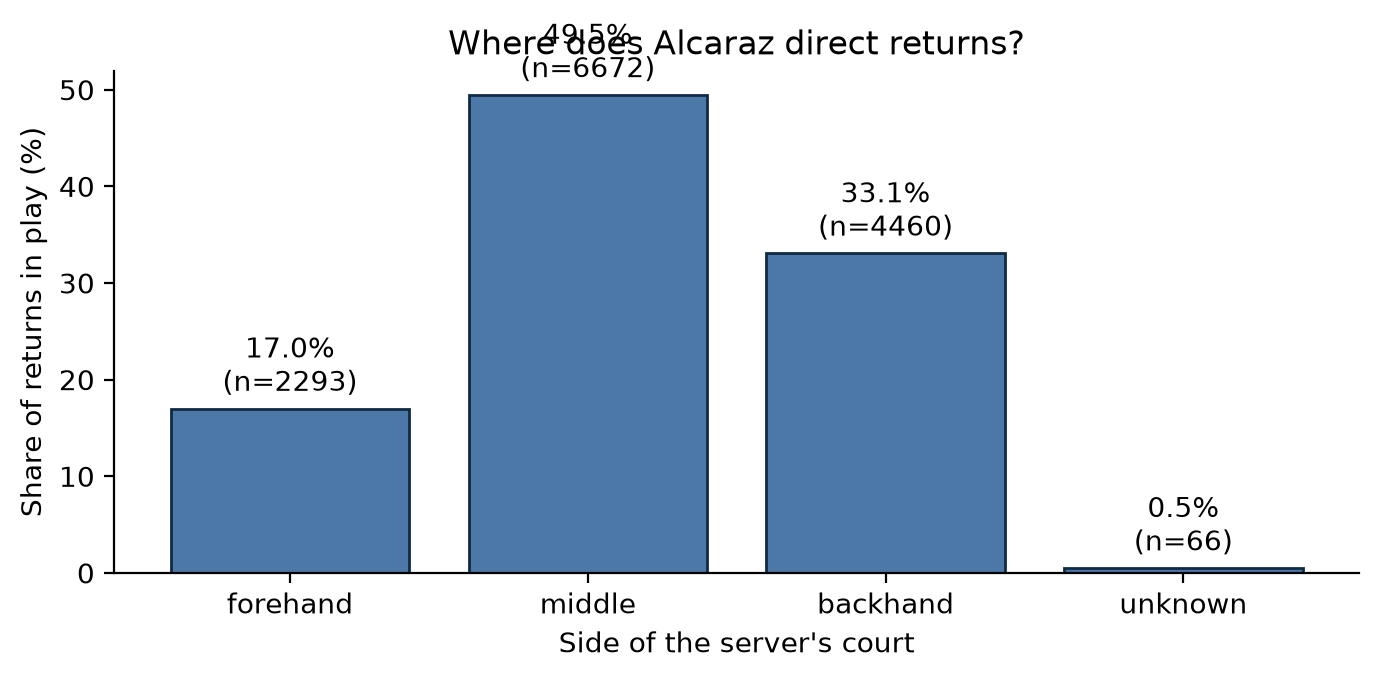

Points  Known_outcomes  Points_won  \
serve_number return_direction                                       
1            forehand            1303            1303         707   
             middle              4578            4578        2147   
             backhand            2366            2366        1194   
             unknown               42              42          20   
2            forehand             990             990         662   
             middle              2094            2094        1128   
             backhand            2094            2094        1289   
             unknown               24              24          14   

                               Success rate (%)  
serve_number return_direction                    
1            forehand                     54.26  
             middle                        46.9  
             backhand                     50.46  
             unknown                      47.62  
2            forehand                     66.87  
             middle                       53.87  
             backhand                     61.56  
             unknown                      58.33

In [19]:
returns_in_play = alcaraz_patterns.copy()
returns_in_play["return_direction"] = pd.Categorical(
    returns_in_play.return_direction.fillna("unknown"),
    ["forehand", "middle", "backhand", "unknown"], ordered=True,
)
direction_summary = performance_table(returns_in_play, ["return_direction"], "alcaraz_won")
direction_summary["Share of returns (%)"] = (100 * direction_summary.Points / len(returns_in_play)).round(2)
fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(direction_summary.index.astype(str), direction_summary["Share of returns (%)"],
              color="#4C78A8", edgecolor="#102A43")
ax.bar_label(bars, labels=[f"{share:.1f}%\n(n={int(n)})" for share, n in
                           zip(direction_summary["Share of returns (%)"], direction_summary.Points)],
             padding=3)
ax.set(xlabel="Side of the server's court", ylabel="Share of returns in play (%)",
       title="Where does Alcaraz direct returns?")
ax.spines[["top", "right"]].set_visible(False); fig.tight_layout(); plt.show()
display(performance_table(returns_in_play, ["serve_number", "return_direction"], "alcaraz_won"))

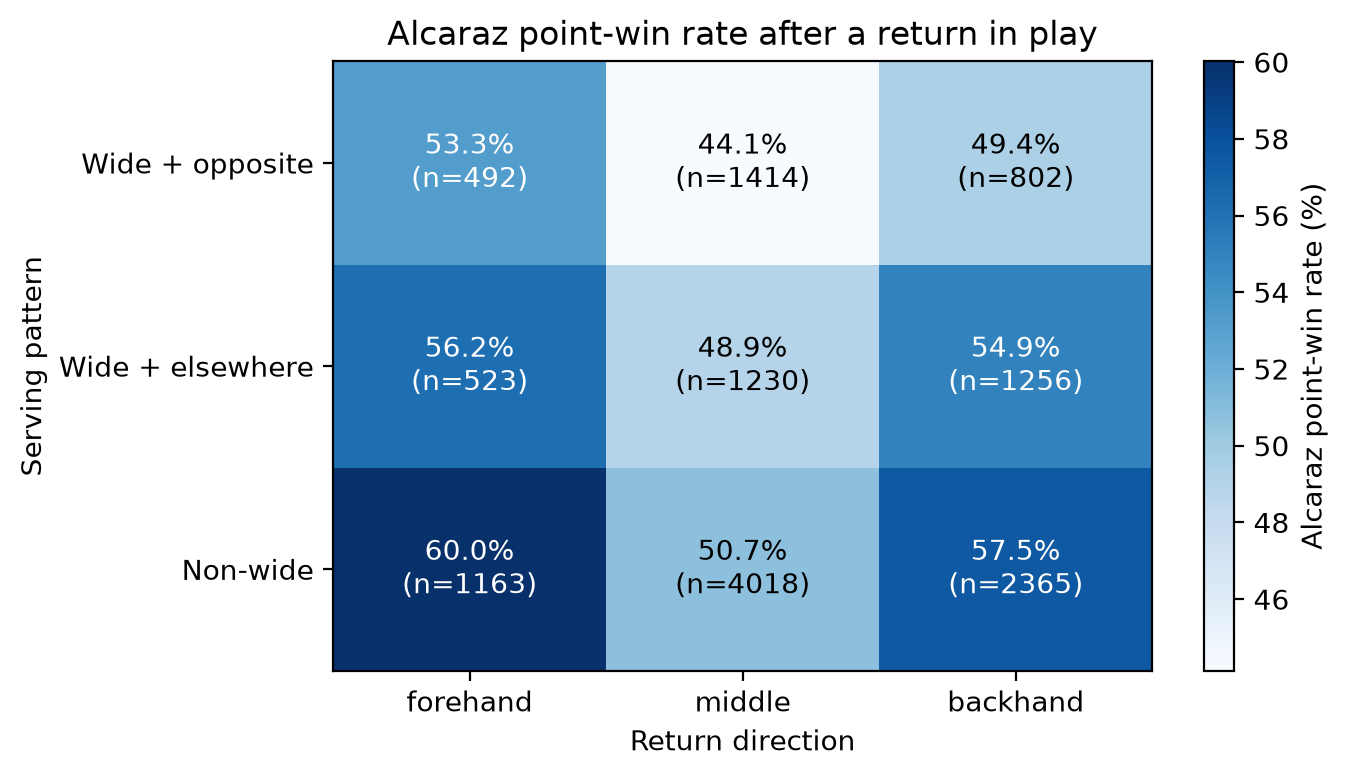

In [20]:
joint_points = alcaraz_classified.dropna(subset=["return_direction"]).copy()
direction_order = ["forehand", "middle", "backhand"]
joint_summary = joint_points.groupby(["strategy", "return_direction"], observed=True).agg(
    Points=("server_won", "size"),
    Opponent_success_rate=("server_won", "mean"),
    Alcaraz_success_rate=("alcaraz_won", "mean"),
)
counts = joint_summary.Points.unstack().reindex(index=strategy_order, columns=direction_order).fillna(0).astype(int)
opponent_win_rates = 100 * joint_summary.Opponent_success_rate.unstack().reindex(index=strategy_order, columns=direction_order)
alcaraz_win_rates = (100 * joint_summary.Alcaraz_success_rate.unstack()
                     .reindex(index=strategy_order, columns=direction_order)).astype(float)
fig, ax = plt.subplots(figsize=(7, 4))
image = ax.imshow(alcaraz_win_rates, cmap="Blues", aspect="auto")
ax.set_xticks(range(3), direction_order)
ax.set_yticks(range(3), strategy_order)
ax.set(xlabel="Return direction", ylabel="Serving pattern",
       title="Alcaraz point-win rate after a return in play")
midpoint = (alcaraz_win_rates.min().min() + alcaraz_win_rates.max().max()) / 2
for i, strategy in enumerate(strategy_order):
    for j, direction in enumerate(direction_order):
        rate, n = alcaraz_win_rates.loc[strategy, direction], counts.loc[strategy, direction]
        ax.text(j, i, f"{rate:.1f}%\n(n={n})", ha="center", va="center",
                color="white" if rate > midpoint else "black")
fig.colorbar(image, ax=ax, label="Alcaraz point-win rate (%)")
fig.tight_layout(); plt.show()

In [21]:
display(performance_table(joint_points, ["serve_number", "strategy", "return_direction"], "alcaraz_won"))

Points  Known_outcomes  \
serve_number strategy         return_direction                           
1            Wide + opposite  backhand             581             581   
                              forehand             357             357   
                              middle              1166            1166   
             Wide + elsewhere backhand             687             687   
                              forehand             334             334   
                              middle               884             884   
             Non-wide         backhand            1078            1078   
                              forehand             568             568   
                              middle              2520            2520   
2            Wide + opposite  backhand             221             221   
                              forehand             135             135   
                              middle               248             248   
             Wide + elsewhere backhand             569             569   
                              forehand             189             189   
                              middle               346             346   
             Non-wide         backhand            1287            1287   
                              forehand             595             595   
                              middle              1498            1498   

                                                Points_won  Success rate (%)  
serve_number strategy         return_direction                                
1            Wide + opposite  backhand                 269              46.3  
                              forehand                 183             51.26  
                              middle                   495             42.45  
             Wide + elsewhere backhand                 353             51.38  
                              forehand                 177             52.99  
                              middle                   409             46.27  
             Non-wide         backhand                 552             51.21  
                              forehand                 303             53.35  
                              middle                  1235             49.01  
2            Wide + opposite  backhand                 127             57.47  
                              forehand                  79             58.52  
                              middle                   129             52.02  
             Wide + elsewhere backhand                 337             59.23  
                              forehand                 117              61.9  
                              middle                   193             55.78  
             Non-wide         backhand                 808             62.78  
                              forehand                 395             66.39  
                              middle                   804             53.67

### Middle is not enough: what about depth?

A short middle return can offer an easy attack; a deep middle return may constrain
the next shot. We should not identify "middle" with "body": the latter would require
server position relative to the ball. Nor do these data establish why Alcaraz chose,
or was forced into, a particular return.

This table checks why the all-middle win rate and the later **deep-middle** payoff
need not agree. They use different subsets, not different definitions of who won.

All middle returns, Alcaraz win rate (%): 44.13


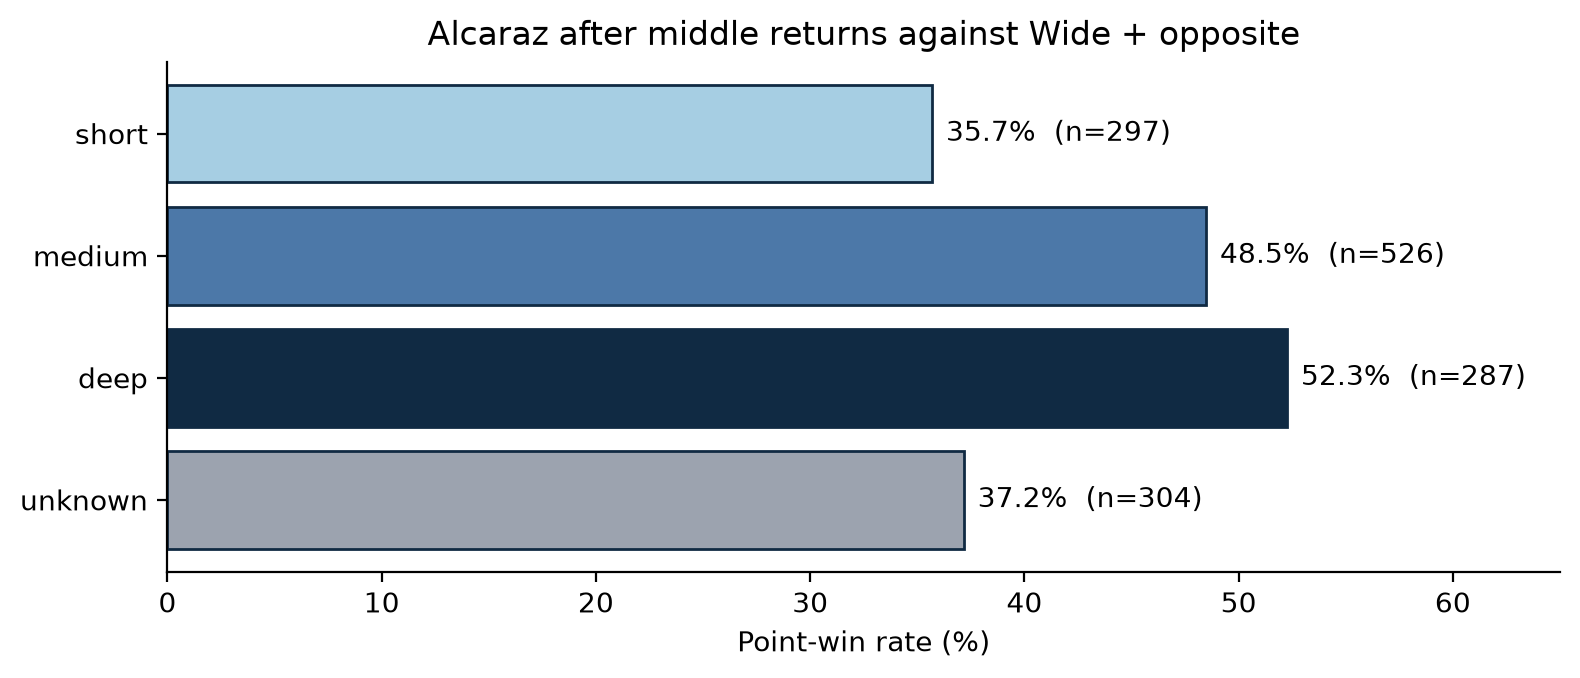

In [22]:
middle_against_wide_opposite = alcaraz_patterns[
    alcaraz_patterns.strategy.eq("Wide + opposite")
    & alcaraz_patterns.return_direction.eq("middle")
].copy()
middle_against_wide_opposite["return_depth"] = middle_against_wide_opposite.return_depth.fillna("unknown")
depth_summary = performance_table(middle_against_wide_opposite, ["return_depth"], "alcaraz_won")
depth_summary = depth_summary.reindex(["short", "medium", "deep", "unknown"]).dropna(how="all")
plot_success_rates(depth_summary, "Alcaraz after middle returns against Wide + opposite",
                   colors=["#A6CEE3", "#4C78A8", "#102A43", "#9CA3AF"][:len(depth_summary)]);
print("All middle returns, Alcaraz win rate (%):",
      round(100 * middle_against_wide_opposite.alcaraz_won.mean(), 2))

## 5. From outcomes to an exploratory 2 × 2 game

Rows: **Wide + opposite / other patterns**. Columns: **deep middle / other returns**.

We deliberately use **two historical populations**:
- $A_{ij}$: Shelton's server win rate in cell $(i,j)$, against his opponents.
- $B_{ij}$: Alcaraz's returner win rate in that cell, against his opponents.

These are performance proxies in a constructed general-sum game. They **do not sum
to one** and are not joint matchup win probabilities. In a model of the same actual
point, the two win probabilities would instead be complements. Head-to-head points
contribute once to each relevant player's source, not twice within a source.

The abstraction treats recorded return profiles and patterns as if players could
adjust their frequencies. Execution difficulty, sequential decisions, and opponent
adaptation are not estimated. This makes the game useful for discussion, not a tactical
prescription or a forecast. Do not interpret a favorable conditional outcome as an
unconditionally available action.

### Classify without turning unknowns into "other"

A non-wide serve is definitely not Wide + opposite even if no follow-up exists.
A wide serve with unknown follow-up remains unknown. Similarly, a non-middle return
or a known short/medium return is definitely not deep-middle; when neither fact is
known, the profile remains unclassified.

In [23]:
row_labels = ["Wide + opposite", "Other patterns"]
column_labels = ["Deep middle return", "Other returns"]


def classify_game_points(frame, outcome):
    result = frame[frame.return_in_play.eq(True)].copy()
    wide_opposite = result.serve_wide & result.serve_plus_one_to_opposite_side
    middle = result.return_direction.astype("string").eq("middle")
    deep = result.return_depth.astype("string").eq("deep")
    result["serve_pattern"] = wide_opposite.map({True: row_labels[0], False: row_labels[1]})
    result["return_profile"] = (middle & deep).map({True: column_labels[0], False: column_labels[1]})
    result["payoff"] = result[outcome].astype("boolean")
    return result

shelton_game_points = classify_game_points(shelton_serve_points, "point_won")
alcaraz_game_points = classify_game_points(alcaraz_return_points, "alcaraz_won")
required = ["serve_pattern", "return_profile", "payoff"]
coverage = pd.DataFrame({name: {
    "Returns in play": len(frame),
    "Classified with known outcome": int(frame[required].notna().all(axis=1).sum()),
} for name, frame in {"Shelton serving": shelton_game_points,
                     "Alcaraz returning": alcaraz_game_points}.items()}).T
display(coverage)
shelton_game_points = shelton_game_points.dropna(subset=required).copy()
alcaraz_game_points = alcaraz_game_points.dropna(subset=required).copy()

,Returns in play,Classified with known outcome
Shelton serving,2565,2266
Alcaraz returning,13491,12069


In [24]:
def estimate_payoffs(frame):
    summary = frame.groupby(["serve_pattern", "return_profile"]).payoff.agg(["mean", "size"])
    payoffs = summary["mean"].unstack().reindex(index=row_labels, columns=column_labels).astype(float)
    counts = summary["size"].unstack().reindex(index=row_labels, columns=column_labels).fillna(0).astype(int)
    return payoffs, counts

shelton_payoffs, shelton_counts = estimate_payoffs(shelton_game_points)
alcaraz_payoffs, alcaraz_counts = estimate_payoffs(alcaraz_game_points)
A, B = shelton_payoffs.to_numpy(), alcaraz_payoffs.to_numpy()
assert np.isfinite(A).all() and np.isfinite(B).all(), "An empty payoff cell needs more data"
for player, payoffs, counts in [("Shelton", shelton_payoffs, shelton_counts),
                                ("Alcaraz", alcaraz_payoffs, alcaraz_counts)]:
    print(player + " payoffs and sample sizes")
    display(payoffs.round(4)); display(counts)
    payoffs.to_csv(OUTPUT_DIR / f"{player.lower()}_payoffs.csv")
    counts.to_csv(OUTPUT_DIR / f"{player.lower()}_counts.csv")

Shelton payoffs and sample sizes


return_profile,Deep middle return,Other returns
serve_pattern,,
Wide + opposite,0.4648,0.5630
Other patterns,0.4215,0.5068


return_profile,Deep middle return,Other returns
serve_pattern,,
Wide + opposite,71,389
Other patterns,344,1462


Alcaraz payoffs and sample sizes


return_profile,Deep middle return,Other returns
serve_pattern,,
Wide + opposite,0.5226,0.4813
Other patterns,0.5785,0.5364


return_profile,Deep middle return,Other returns
serve_pattern,,
Wide + opposite,287,2117
Other patterns,1324,8341


### How sensitive is the pooled picture to serve number?

First- and second-serve cells can tell different stories. Inspect both before treating
pooled incentives as a stable tactical finding. Counts are shown alongside every matrix.
The notebook does not estimate causal effects or formal confidence intervals; sparse
cells and differences among opponents remain important limitations.

In [25]:
for serve_number in [1, 2]:
    print(f"Serve number {serve_number}")
    for player, frame in [("Shelton", shelton_game_points), ("Alcaraz", alcaraz_game_points)]:
        payoff, count = estimate_payoffs(frame[frame.serve_number.eq(serve_number)])
        print(player)
        display(payoff.round(4)); display(count)

Serve number 1
Shelton


return_profile,Deep middle return,Other returns
serve_pattern,,
Wide + opposite,0.5185,0.5918
Other patterns,0.4426,0.5339


return_profile,Deep middle return,Other returns
serve_pattern,,
Wide + opposite,54,294
Other patterns,183,871


Alcaraz


return_profile,Deep middle return,Other returns
serve_pattern,,
Wide + opposite,0.4915,0.4599
Other patterns,0.5674,0.4914


...

return_profile,Deep middle return,Other returns
serve_pattern,,
Wide + opposite,0.2941,0.4737
Other patterns,0.3975,0.4670


return_profile,Deep middle return,Other returns
serve_pattern,,
Wide + opposite,17,95
Other patterns,161,591


Alcaraz


return_profile,Deep middle return,Other returns
serve_pattern,,
Wide + opposite,0.6667,0.5492
Other patterns,0.5961,0.5935


return_profile,Deep middle return,Other returns
serve_pattern,,
Wide + opposite,51,508
Other patterns,515,3673


### Export readable payoff tables

Both tables retain the same row/column convention. Headers are bold; numerical
payoffs are not. A single figure is displayed and exported as PDF and PNG.

In [26]:
def save_figure(fig, name):
    fig.savefig(OUTPUT_DIR / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight", dpi=180)

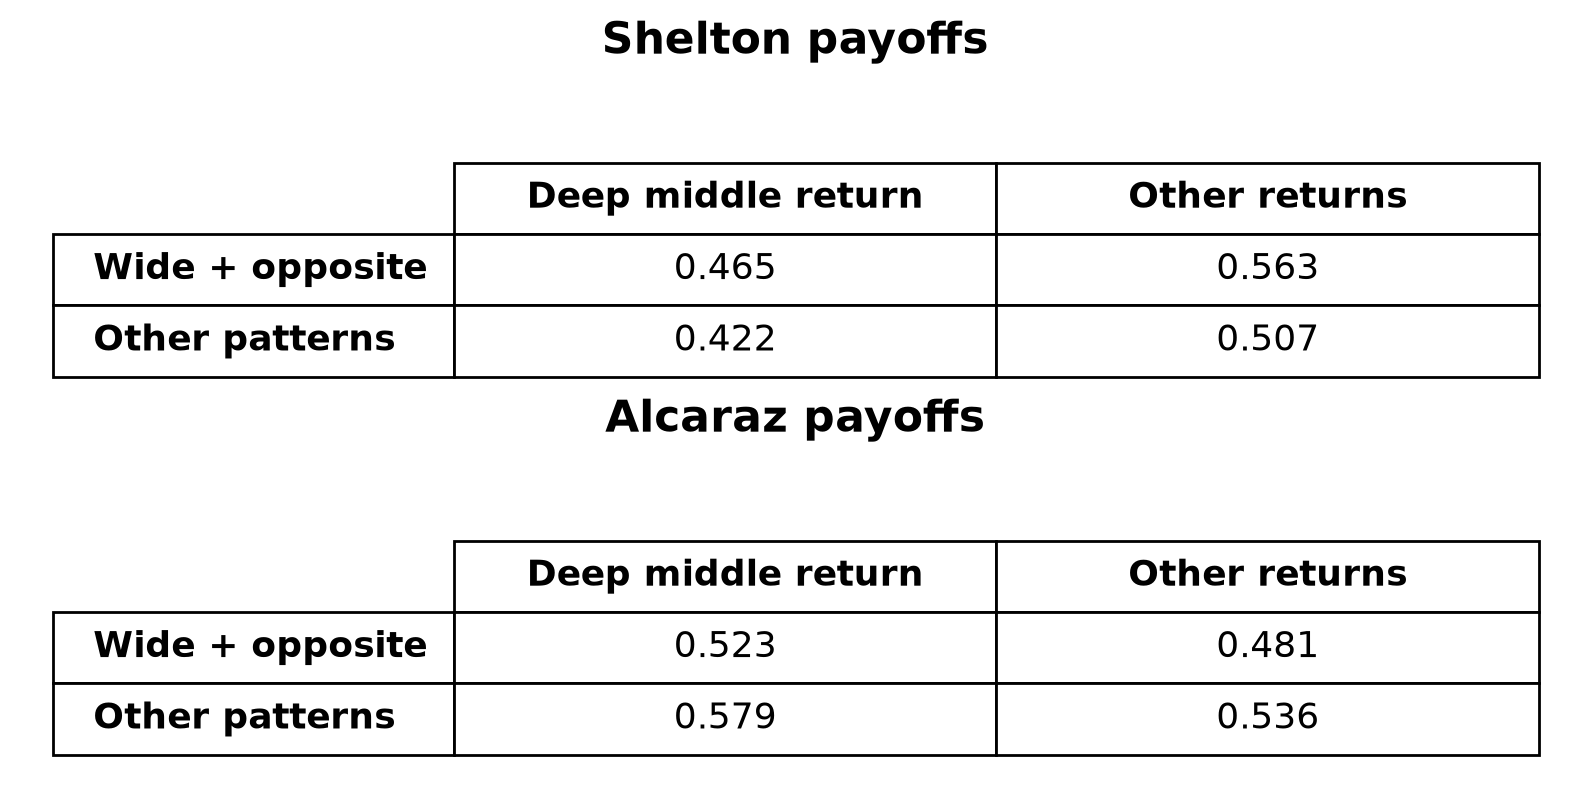

In [27]:
matrix_fig, axes = plt.subplots(2, 1, figsize=(10, 4.5))
for ax, matrix, player in zip(axes, [A, B], ["Shelton", "Alcaraz"]):
    ax.axis("off")
    ax.set_title(player + " payoffs", fontsize=16, fontweight="bold", pad=12)
    table = ax.table(cellText=[[f"{v:.3f}" for v in row] for row in matrix],
                     rowLabels=row_labels, colLabels=column_labels,
                     cellLoc="center", bbox=[.28, .08, .7, .68])
    table.auto_set_font_size(False)
    table.set_fontsize(13)
    for (r, c), cell in table.get_celld().items():
        cell.set_text_props(weight="bold" if r == 0 or c == -1 else "normal")
save_figure(matrix_fig, "payoff_matrices")
plt.show()

## 6. What would adaptation look like under these payoffs?

Let $x$ be Shelton's Wide + opposite frequency and $y$ Alcaraz's deep-middle
frequency. Under two-population replicator updating:

$$
\dot x=x(1-x)\{y(A_{11}-A_{21})+(1-y)(A_{12}-A_{22})\},
$$
$$
\dot y=y(1-y)\{x(B_{11}-B_{12})+(1-x)(B_{21}-B_{22})\}.
$$

These equations describe one assumed payoff-based updating rule with **fixed scores**.
They are not a prediction of real-time player learning. Strictly positive differences
in both columns/rows imply dominant first actions in this fitted game; other data
could produce a different result.

The two displayed payoff matrices use the same table layout: Shelton's patterns are
rows and Alcaraz's return profiles are columns.

Pynamo uses player-specific payoff matrices: each player's own actions appear in the
rows and the opponent's actions in the columns. Therefore, Shelton's displayed matrix
**A** can be passed directly to pynamo, while Alcaraz's displayed matrix **B** must be
transposed. All displayed payoffs and score calculations continue to use the original
untransposed **B**.

In [28]:
PYNAMO_RELEASE = "v0.2.0"
%pip install --quiet --force-reinstall --no-deps "pynamo-egt @ git+https://github.com/SlimaneD/pynamo.git@v0.2.0"

import pynamo_egt as pn

B_for_pynamo = B.T
print("Shelton Wide + opposite minus other scores:", A[0] - A[1])
print("Alcaraz deep-middle-minus-other scores:", B[:, 0] - B[:, 1])

Note: you may need to restart the kernel to use updated packages.


Shelton Wide + opposite minus other scores: [0.0432771  0.05614206]
Alcaraz deep-middle-minus-other scores: [0.04130656 0.04216332]


In [29]:
navy, tennis_yellow, light_gray = "#102A43", "#DFFF00", "#B8BEC8"
tennis_blues = LinearSegmentedColormap.from_list("blue_to_black", ["#2389DA", "#104A80", "#000000"])
game = pn.Game(
    name="Shelton--Alcaraz: exploratory adaptation model",
    payoffs=(A, B_for_pynamo), player_strategy_labels=[row_labels, column_labels],
    player_labels=["Shelton", "Alcaraz"], symmetric=False,
)
phase_style = dict(
    show_speed=True, speed_cmap=tennis_blues, speed_levels=30,
    trajectory_color="white", trajectory_linewidth=1.8,
    sink_color=tennis_yellow, saddle_color=light_gray, source_color="white",
    center_color=light_gray, equilibrium_edgecolor=navy, equilibrium_size=150,
)

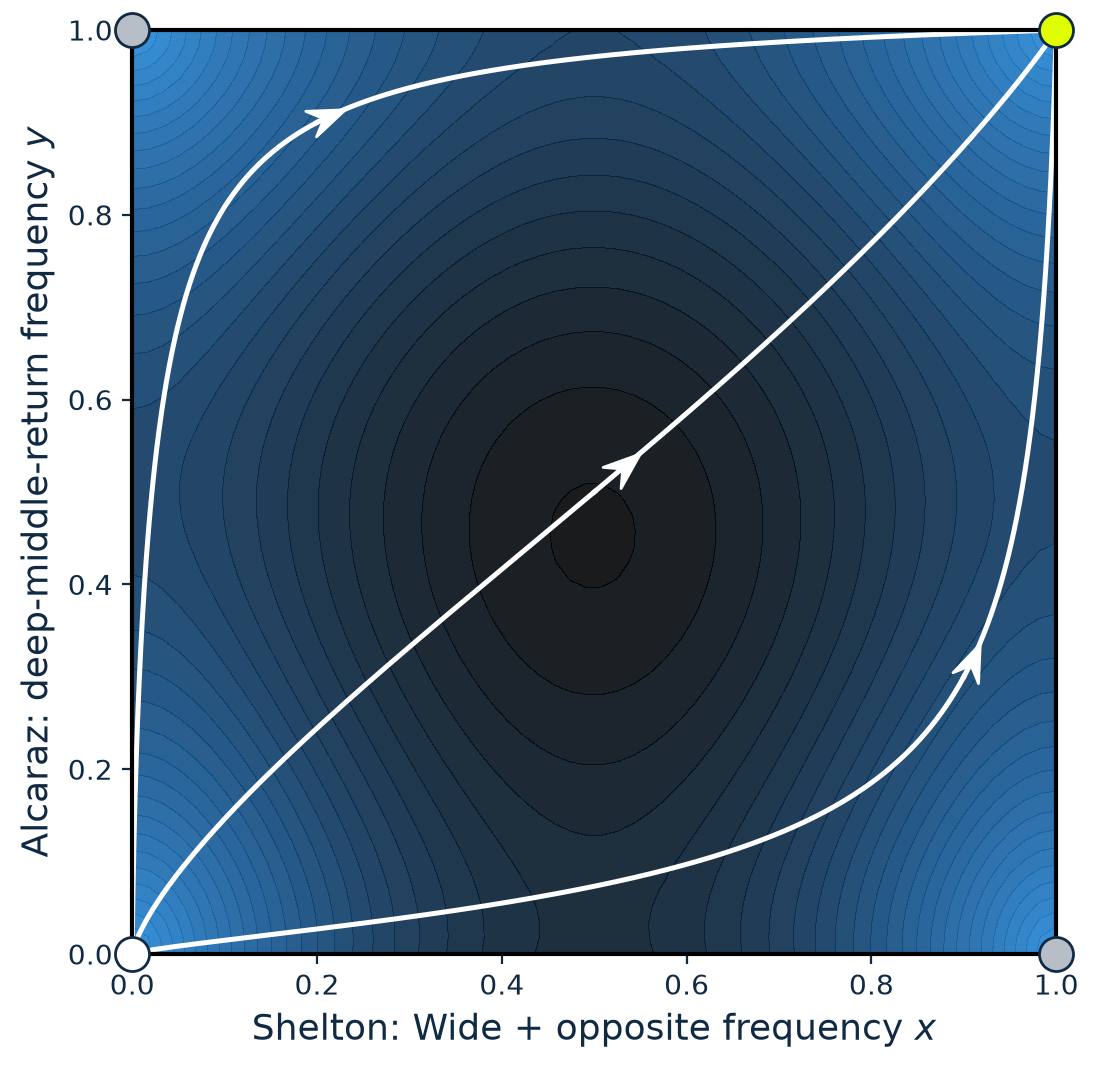

In [30]:
phase_fig, phase_ax = pn.phase_portrait(
    game, starts=[[.2, .9], [.9, .3], [.5, .5]], tmax=200, **phase_style,
)
phase_ax.set_xlabel(r"Shelton: Wide + opposite frequency $x$", color=navy)
phase_ax.set_ylabel(r"Alcaraz: deep-middle-return frequency $y$", color=navy)
phase_ax.set_title("")
phase_ax.tick_params(colors=navy)
for spine in phase_ax.spines.values():
    spine.set_color(navy)
phase_fig.patch.set_facecolor("white")
save_figure(phase_fig, "shelton_alcaraz_phase_portrait")
plt.show()

## 7. Where do historical frequencies sit on the performance map?

For independent mixtures, each score is the probability-weighted average of its four
entries. We plot $u_S(x,y)-u_A(x,y)$, **not** Shelton's probability of beating Alcaraz.
Blue means a higher Shelton historical score; red means a higher Alcaraz score. The
zero contour is an **equal-performance-score boundary**, not a winning threshold.

The scores come from different populations and the observed variables are sequentially
related. Combining marginal frequencies as independent mixtures is part of the model,
not an observed joint distribution of their head-to-head play.

In [31]:
def expected_payoff(matrix, x, y):
    return (x*y*matrix[0, 0] + x*(1-y)*matrix[0, 1]
            + (1-x)*y*matrix[1, 0] + (1-x)*(1-y)*matrix[1, 1])

grid = np.linspace(0, 1, 301)
X, Y = np.meshgrid(grid, grid)
difference = expected_payoff(A, X, Y) - expected_payoff(B, X, Y)
limit = max(float(np.abs(difference).max()), 1e-6)
norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

x_count, x_total = int(shelton_counts.loc["Wide + opposite"].sum()), int(shelton_counts.to_numpy().sum())
y_count, y_total = int(alcaraz_counts["Deep middle return"].sum()), int(alcaraz_counts.to_numpy().sum())
x_historical, y_historical = x_count / x_total, y_count / y_total
n_deep_middle = int(alcaraz_counts.loc["Wide + opposite", "Deep middle return"])
n_total = int(alcaraz_counts.loc["Wide + opposite"].sum())
x_observed, y_observed = 1.0, n_deep_middle / n_total

### Two points, two different interpretations

- **Gray — historical reference:** Shelton's overall Wide + opposite share and Alcaraz's
  overall deep-middle share, among the classified points used in each payoff table.
- **Yellow — 100% Wide + opposite scenario:** Wide + opposite frequency 1, paired with Alcaraz's
  deep-middle frequency **conditional on facing Wide + opposite**.

This preserves the original figure's scenario. The arrow changes **both coordinates**;
its label describes increasing Wide + opposite use but does not imply the return mix stays fixed.
For a fixed-return-mix scenario, explicitly replace `y_observed` with `y_historical`.
Neither point is an estimated head-to-head joint distribution. Excluded unknown profiles
are not counted as other returns or included in these frequency denominators.

The following small drawing helpers keep the plotting cell readable. Edit label offsets
in these helpers to adjust layout without changing the statistical calculation.

In [32]:
def draw_score_boundary(ax):
    if difference.min() < 0 < difference.max():
        contour = ax.contour(X, Y, difference, levels=[0], colors="black", linewidths=1.5)
        ax.clabel(contour, fmt={0: "Equal performance scores"}, fontsize=11,
                  manual=[(.6, .4)])
    if np.all(A[0] > A[1]) and np.all(B[:, 0] > B[:, 1]):
        ax.scatter([1], [1], s=110, color="black", clip_on=False, zorder=5)
        ax.annotate("Stable equilibrium", xy=(1, 1), xytext=(-15, -25),
                    textcoords="offset points", ha="right")


def draw_reference_points(ax):
    ax.scatter(x_observed, y_observed, s=160, facecolor="gold", edgecolor="black",
               linewidth=1.5, clip_on=False, zorder=10)
    ax.annotate("100% Wide + opposite scenario\n" + rf"$y={y_observed:.3f}$"
                + f" ({n_deep_middle}/{n_total} points)", xy=(x_observed, y_observed),
                xytext=(-20, 25), textcoords="offset points", ha="right", va="bottom",
                arrowprops=dict(arrowstyle="->", color="black"),
                bbox=dict(facecolor="white", alpha=.9, edgecolor="gray"), zorder=11)
    ax.scatter(x_historical, y_historical, s=110, facecolor="#9CA3AF",
               edgecolor="#111827", linewidth=1.3, zorder=12)
    ax.annotate("Historical frequencies\n" + rf"$x$ ({x_count}/{x_total})" + "\n"
                + rf"$y$ ({y_count}/{y_total})", xy=(x_historical, y_historical),
                xytext=(20, 25), textcoords="offset points", ha="left", va="bottom",
                arrowprops=dict(arrowstyle="->", color="black"),
                bbox=dict(facecolor="white", alpha=.9, edgecolor="gray"), zorder=12)

In [33]:
def draw_scenario_arrow(ax):
    movement = ax.annotate("", xy=(x_observed, y_observed),
        xytext=(x_historical, y_historical),
        arrowprops=dict(arrowstyle="-|>", color="olivedrab", lw=2.5,
                        mutation_scale=20, shrinkA=9, shrinkB=10), zorder=8)
    movement.arrow_patch.set_path_effects([
        pe.Stroke(linewidth=4, foreground=navy), pe.Normal(),
    ])
    ax.annotate("More Wide + opposite use",
        xy=((x_historical+x_observed)/2, (y_historical+y_observed)/2),
        xytext=(0, -18), textcoords="offset points", ha="center", va="bottom",
        fontsize=11, color=navy,
        bbox=dict(facecolor="white", edgecolor="none", alpha=.9, pad=3), zorder=9)

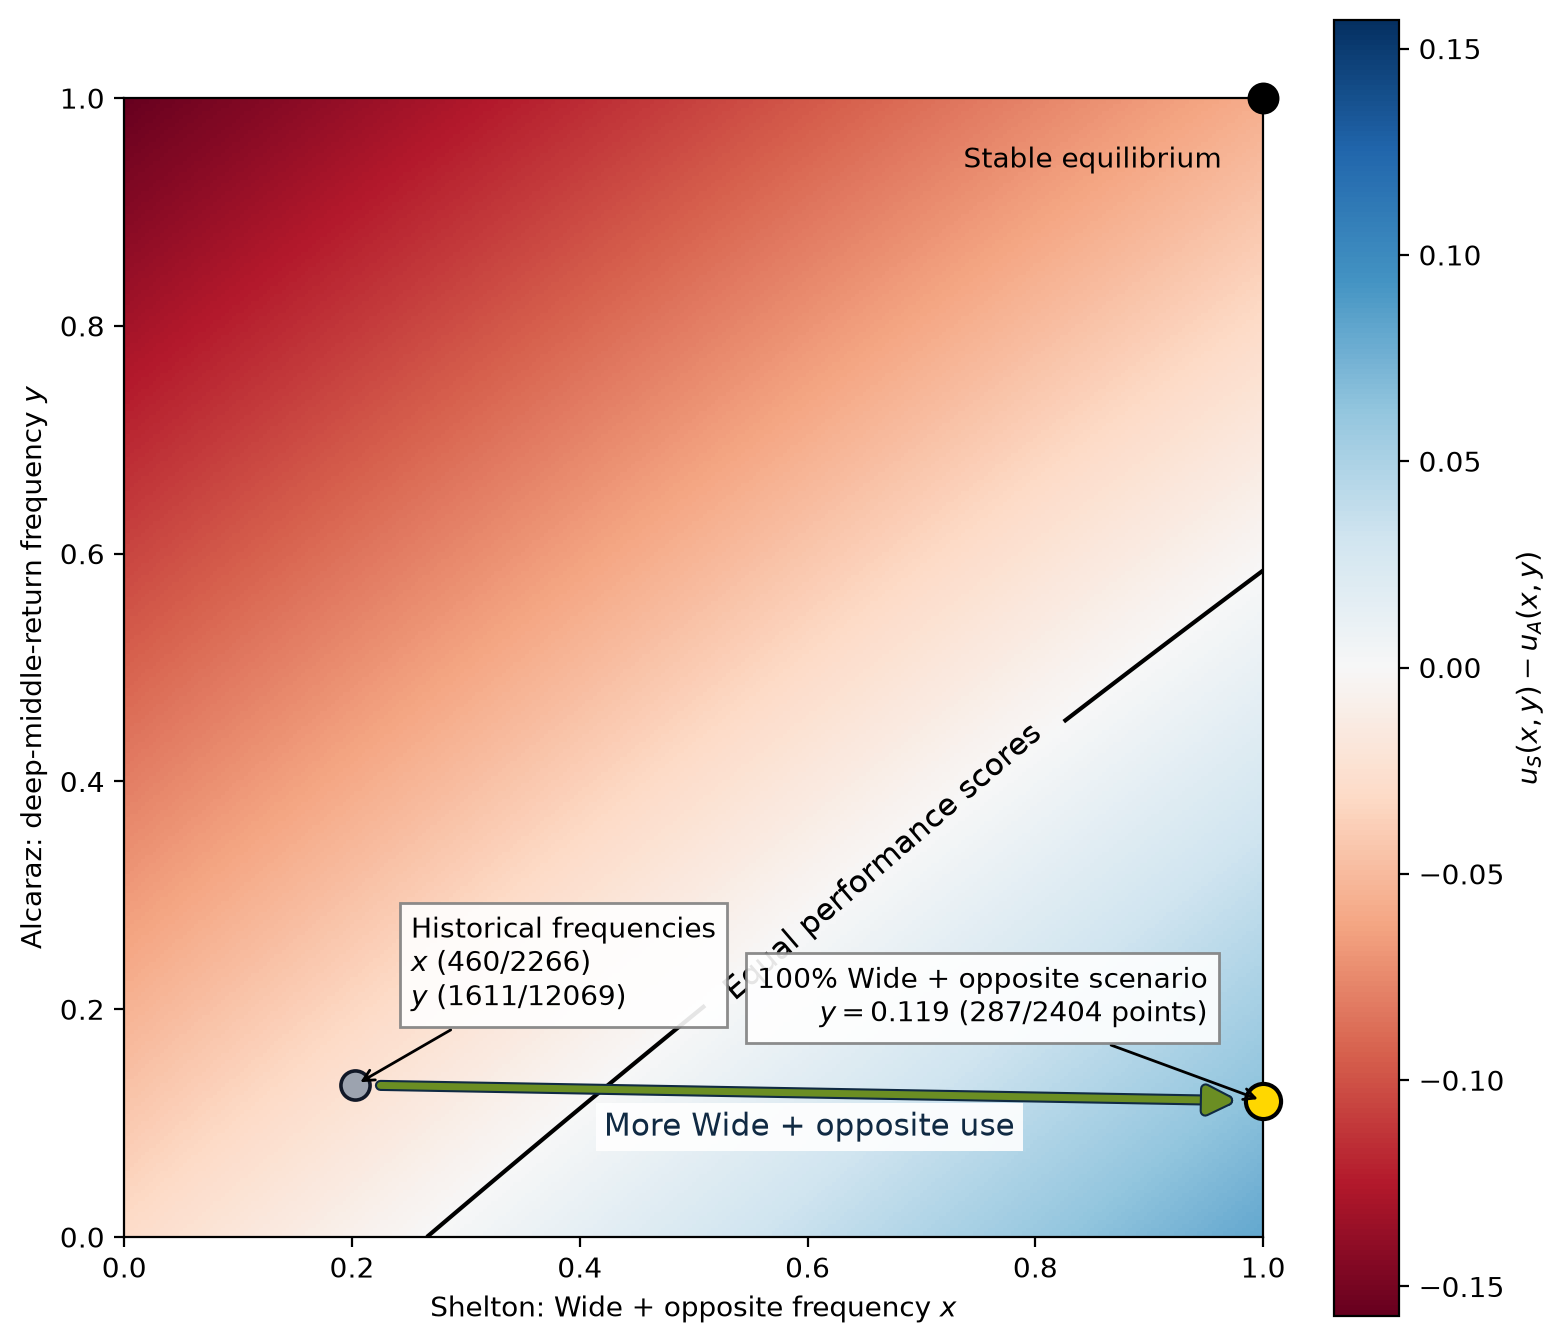

In [34]:
difference_fig, difference_ax = plt.subplots(figsize=(8, 7))
heatmap = difference_ax.pcolormesh(X, Y, difference, shading="auto", cmap="RdBu",
                                 norm=norm, rasterized=True)
colorbar = difference_fig.colorbar(heatmap, ax=difference_ax)
colorbar.set_label(r"$u_S(x,y)-u_A(x,y)$")
draw_score_boundary(difference_ax)
draw_reference_points(difference_ax)
draw_scenario_arrow(difference_ax)
difference_ax.set(xlabel=r"Shelton: Wide + opposite frequency $x$",
                  ylabel=r"Alcaraz: deep-middle-return frequency $y$",
                  xlim=(0, 1), ylim=(0, 1))
difference_ax.set_aspect("equal")
difference_fig.tight_layout()
save_figure(difference_fig, "shelton_alcaraz_payoff_difference")
plt.show()

### Check the plotted story numerically

Crossing the score boundary compares two historical scores. The separate last column
below compares **Shelton's Wide + opposite and other-pattern scores at the same y**, which is
the relevant within-model incentive for changing his own pattern. No column estimates
the causal effect of changing tactics or the probability of winning the match.

In [35]:
scenarios = {"Historical reference": (x_historical, y_historical),
             "100% Wide + opposite, pattern-conditioned return mix": (x_observed, y_observed),
             "100% Wide + opposite, fixed historical return mix": (1, y_historical),
             "Both first actions": (1, 1)}
scenario_table = pd.DataFrame({name: {
    "x": x, "y": y,
    "Shelton score": expected_payoff(A, x, y),
    "Alcaraz score": expected_payoff(B, x, y),
    "Score difference": expected_payoff(A, x, y) - expected_payoff(B, x, y),
    "Shelton Wide + opposite minus other at this y": expected_payoff(A, 1, y) - expected_payoff(A, 0, y),
} for name, (x, y) in scenarios.items()}).T
display(scenario_table.round(4))
scenario_table.to_csv(OUTPUT_DIR / "scenario_scores.csv")

,x,y,Shelton score,Alcaraz score,Score difference,Shelton Wide + opposite minus other at this y
Historical reference,0.203,0.1335,0.5065,0.5308,-0.0243,0.0544
"100% Wide + opposite, pattern-conditioned return mix",1.000,0.1194,0.5513,0.4863,0.0650,0.0546
"100% Wide + opposite, fixed historical return mix",1.000,0.1335,0.5499,0.4869,0.0630,0.0544
Both first actions,1.000,1.0000,0.4648,0.5226,-0.0579,0.0433


## 8. What can we say, and what remains open?

The descriptive tables investigate whether wide serve → opposite-side serve+1 is
associated with better outcomes for Shelton and against Alcaraz. The deeper return
breakdown explains why all-middle returns and deep-middle returns can tell different
stories. The fitted game then illustrates adaptation under explicit performance-score
assumptions, with the historical reference grounding the scenarios in observed counts.

**Limits to carry into publication:**
- These are charted matches, not necessarily representative of all matches or the
  conditions of a future encounter. The primary estimates pool surfaces and opponents.
- Wide + opposite is identified after the return; it may be easier to execute after
  weak returns. Missing annotations and the return-winner asymmetry affect selection.
- Serve+1 depth, spin, serve speed and player positioning are not measured here.
- Deep-middle return frequency measures observed outcomes, not the success rate of an
  intended return policy. A 100% frequency is not established as physically achievable.
- The game uses separate historical populations and independent mixtures of sequential
  events. Its score boundary is not a matchup-winning threshold.
- Counts show the evidence base; uncertainty, opponent-adjusted estimates and causal
  identification require further work.

**Next questions:** Is the Wide + opposite advantage unusually large for Shelton relative
to comparable servers (question 2)? Does it persist within opponents, court sides and
surfaces? How do head-to-head and left-handed-server subsets compare? Can video establish
return intention, body placement and recovery position?

The model offers a transparent discussion scenario rather than a recommendation to
maximize a pattern. AI-assisted coding accelerated exploration; the assumptions and
checks above define what the resulting analysis supports.

## 9. Record the run

The hashes identify the exact data files. Repository revisions identify the source
checkouts; a revision alone does not capture local modifications, so the status is also
recorded. Package versions and the pynamo module location identify the runtime. Re-run
this cell after using a different environment or data snapshot.

**Before sharing:** restart the kernel and run all cells, inspect the counts and figures,
and keep the exported files and executed notebook together. The notebook contains all
analysis code; the external feature script and earlier exploratory script are not needed.

In [36]:
import hashlib
import importlib.metadata
import subprocess

def file_hash(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def git_info(path, *arguments):
    result = subprocess.run(["git", "-C", str(path), *arguments], capture_output=True, text=True)
    return result.stdout.strip() if result.returncode == 0 else "unavailable"

provenance = pd.DataFrame({name: {"Filename": path.name, "SHA256": file_hash(path)}
                           for name, path in data_files.items()}).T
provenance.to_csv(OUTPUT_DIR / "input_provenance.csv")
display(provenance)
print("Pinned data revision:", DATA_REVISION)
if DATA_DIR == LOCAL_DATA_DIR:
    print("Local checkout revision:", git_info(DATA_DIR, "rev-parse", "HEAD"))
    print("Local data modifications:", git_info(DATA_DIR, "status", "--short") or "none")
print("Pynamo release:", PYNAMO_RELEASE)
print("Pynamo loaded from:", pn.__file__)
print("Python:", sys.version.split()[0])
versions = {package: importlib.metadata.version(package)
            for package in ["numpy", "pandas", "matplotlib", "scipy", "sympy", "ipython", "pynamo-egt"]}
display(pd.Series(versions, name="Version"))
print("Exports:", OUTPUT_DIR.resolve())

,Filename,SHA256
matches,charting-m-matches.csv,d8dce1ad8d12c04efa01da587441b54ece8e8100530660...
points,charting-m-points-2020s.csv,2cd43f73e0530a47ea4c02b99dae40177ca6d58a8ccf91...


Pinned data revision: 2c59eef194967e688b69e73df344184a06322cd8
Local checkout revision: 2c59eef194967e688b69e73df344184a06322cd8
Local data modifications: none
Pynamo release: v0.2.0
Pynamo loaded from: /Users/slimane/Documents/GitHub/Shelton-Alcaraz-USOpen26/.venv/lib/python3.12/site-packages/pynamo_egt/__init__.py
Python: 3.12.1


numpy          2.5.3
pandas         3.0.5
matplotlib    3.11.1
scipy         1.18.1
sympy         1.14.0
ipython       9.17.1
pynamo-egt     0.2.0
Name: Version, dtype: str

Exports: /Users/slimane/Documents/GitHub/Shelton-Alcaraz-USOpen26/notebook_outputs
